In [6]:
import sys
sys.path.insert(0, '../src')

import pandas as pd

from tfm_airquality import config
from tfm_airquality.load import load_airquality_data
from tfm_airquality.clean import clean
from tfm_airquality.clean import gap_runs
from tfm_airquality import eda
import matplotlib.pyplot as plt
import seaborn as sns

df, informe_huecos = clean(load_airquality_data())
print(df.shape)
Y = 'NO2(GT)'
X = ['CO(GT)', 'NOx(GT)',
     'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
     'T', 'RH', 'AH']
variables = X + [Y]

(9357, 14)


# Estación 4 — Análisis descriptivo

## Pregunta 1: ¿qué variables anticipan el NO₂?

La correlación contemporánea entre un sensor y el NO₂ no mide capacidad
predictiva. Este proyecto predice a 24 y 48 horas, así que lo relevante es la
relación entre el valor actual de cada variable y el NO₂ futuro.

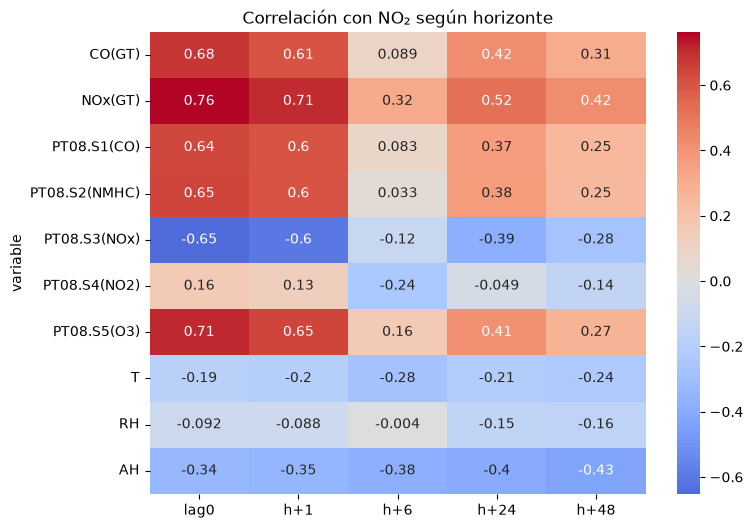

WindowsPath('C:/Users/joser/OneDrive/Documentos/MASTER/TFM/tfm-airquality/reports/figuras/correlacion_por_horizonte.png')

In [9]:
tabla = eda.correlacion_por_horizonte(df, variables=X)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(tabla, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación con NO₂ según horizonte')
plt.show()

eda.guardar_figura(fig, 'correlacion_por_horizonte')

## Pregunta 2: ¿se solapan las variables entre sí?

Dos motivos para mirarlo. Primero, la multicolinealidad afecta a la estabilidad
de los modelos lineales y reparte de forma arbitraria la importancia entre
variables redundantes, lo que complica la interpretabilidad. Segundo, permite
cerrar la sospecha sobre `C6H6(GT)`.

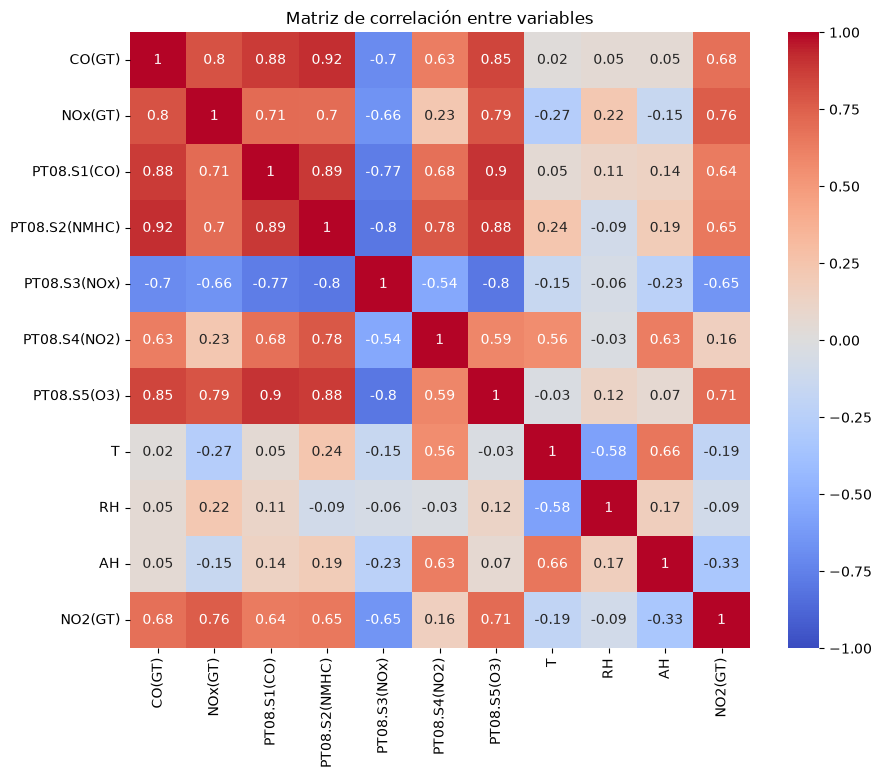

In [10]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(df[variables].corr().round(2), annot=True, cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables')
eda.guardar_figura(fig, 'matriz_correlacion')
plt.show()

In [ ]:
print(df['C6H6(GT)'].nunique())
print(df['PT08.S2(NMHC)'].nunique())

407
1246


In [ ]:
perfil_horario = df.groupby(df.index.hour)[Y].mean()
perfil_semanal = df.groupby(df.index.dayofweek)[Y].mean()
print(perfil_horario)
print(perfil_semanal)

DateTime
0     103.321429
1      90.502994
2      75.436747
3      80.115385
4      58.620482
5      59.612613
6      71.742515
7      94.709581
8     121.268293
9     130.876877
10    133.678571
11    130.413174
12    124.456716
13    119.312312
14    116.468468
15    117.191617
16    123.310448
17    135.804154
18    145.919643
19    150.091988
20    145.118694
21    130.910714
22    115.095522
23    108.071642
Name: NO2(GT), dtype: float64
DateTime
0    110.297683
1    117.393227
2    120.007491
3    120.843889
4    123.452007
5    107.567568
6     91.655300
Name: NO2(GT), dtype: float64


In [ ]:
autocorr = pd.Series({lag: df[Y].autocorr(lag) for lag in range(1, 193)})
print(autocorr)
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168, 192]:
    print(lag, round(df[Y].autocorr(lag), 3))

1      0.899576
2      0.755958
3      0.612144
4      0.490043
5      0.408093
         ...   
188    0.254553
189    0.342495
190    0.442326
191    0.524774
192    0.573009
Length: 192, dtype: float64
1 0.9
2 0.756
3 0.612
6 0.352
12 0.234
24 0.708
48 0.573
72 0.536
96 0.508
120 0.514
144 0.583
168 0.646
192 0.573


In [ ]:
observado = df[Y].dropna()
episodios = observado.where(observado <= 200)
rachas = gap_runs(episodios)

print('episodios:', len(rachas))
print('horas totales:', int(rachas['horas'].sum()), '(deben ser 386)')
print('duración media:', round(rachas['horas'].mean(), 1), 'h')
print('duración máxima:', int(rachas['horas'].max()), 'h')
print(rachas['horas'].value_counts().sort_index().to_dict())

episodios: 136
horas totales: 386 (deben ser 386)
duración media: 2.8 h
duración máxima: 18 h
{1: 47, 2: 32, 3: 28, 4: 11, 5: 4, 6: 4, 7: 1, 8: 4, 9: 1, 10: 1, 12: 1, 15: 1, 18: 1}


In [ ]:
mes = df.index.to_period('M')

corr = pd.DataFrame({
    s: df.groupby(mes).apply(lambda g: g[s].corr(g[Y]), include_groups=False)
    for s in config.SENSOR_COLUMNS
}).round(3)
print(corr)

ratios = pd.DataFrame({
    s: (df.groupby(mes)[Y].mean() / df.groupby(mes)[s].mean()) * 1000
    for s in config.SENSOR_COLUMNS
}).round(1)
print(ratios)

          PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)
DateTime                                                                     
2004-03         0.870          0.908        -0.855         0.835        0.867
2004-04         0.864          0.896        -0.861         0.813        0.833
2004-05         0.771          0.868        -0.788         0.694        0.781
2004-06         0.814          0.865        -0.800         0.748        0.769
2004-07         0.768          0.882        -0.802         0.692        0.708
2004-08         0.624          0.728        -0.634         0.477        0.481
2004-09         0.817          0.842        -0.744         0.688        0.817
2004-10         0.815          0.837        -0.791         0.801        0.815
2004-11         0.647          0.712        -0.625         0.448        0.723
2004-12         0.758          0.849        -0.599         0.536        0.846
2005-01         0.728          0.820        -0.781         0.615

WindowsPath('C:/Users/joser/OneDrive/Documentos/MASTER/TFM/tfm-airquality/reports/figuras/deriva_sensores.png')

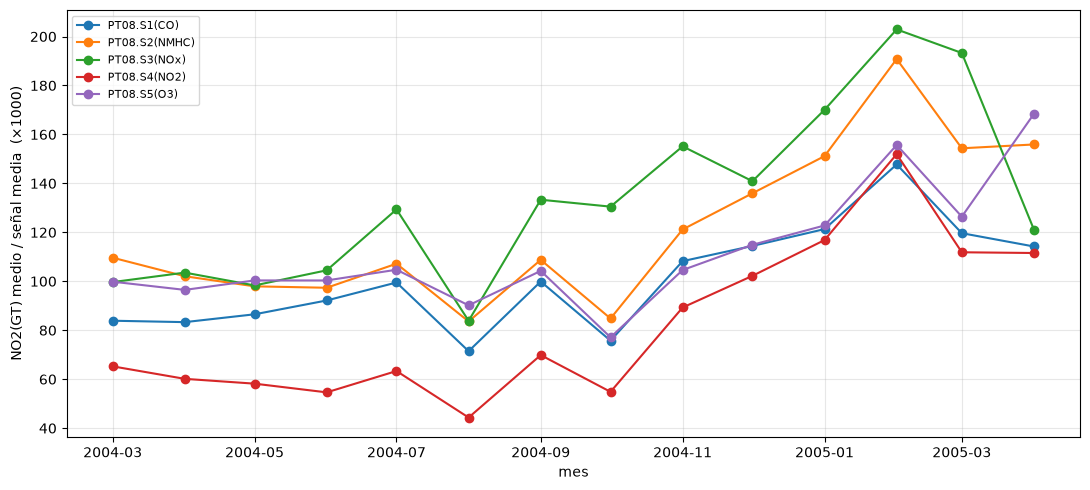

In [3]:
fig = eda.plot_deriva_sensores(df)
eda.guardar_figura(fig, 'deriva_sensores')

WindowsPath('C:/Users/joser/OneDrive/Documentos/MASTER/TFM/tfm-airquality/reports/figuras/simpson_pt08s4.png')

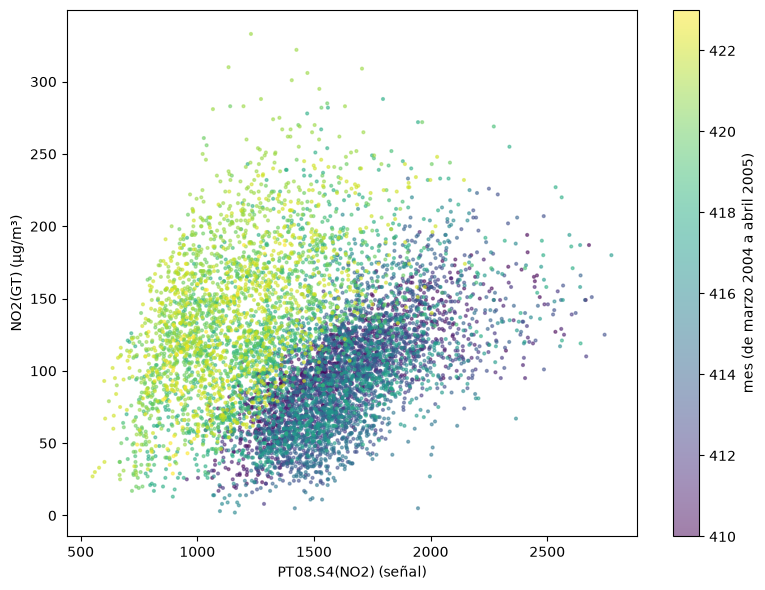

In [4]:
fig = eda.plot_simpson(df)
eda.guardar_figura(fig, 'simpson_pt08s4')

WindowsPath('C:/Users/joser/OneDrive/Documentos/MASTER/TFM/tfm-airquality/reports/figuras/perfiles_temporales.png')

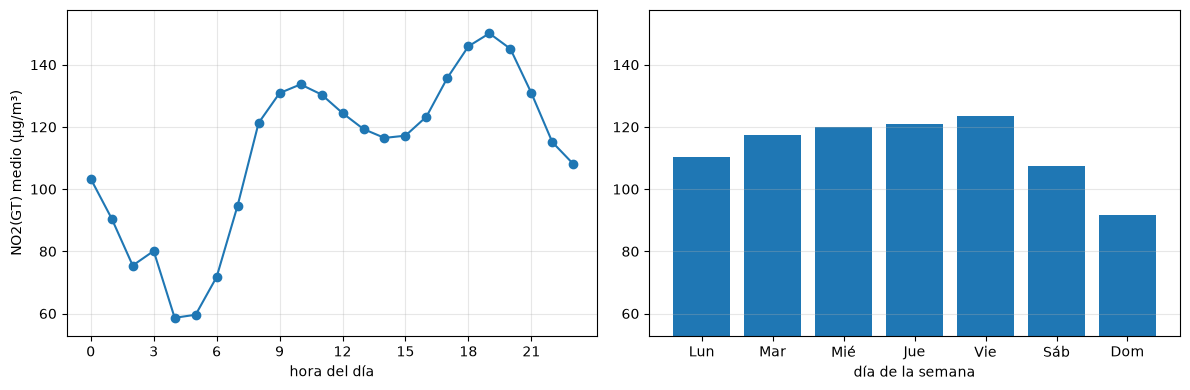

In [11]:
fig = eda.plot_perfiles_temporales(df)
eda.guardar_figura(fig, 'perfiles_temporales')

WindowsPath('C:/Users/joser/OneDrive/Documentos/MASTER/TFM/tfm-airquality/reports/figuras/autocorrelacion.png')

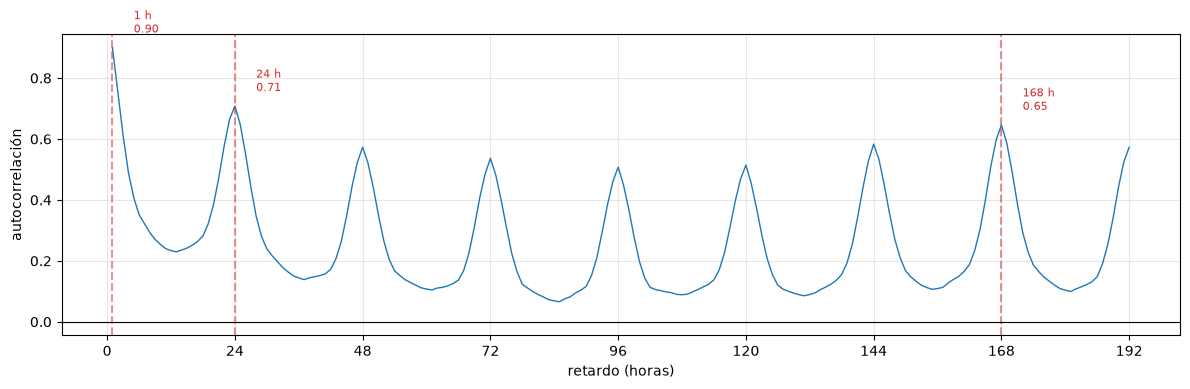

In [12]:
fig = eda.plot_autocorrelacion(df)
eda.guardar_figura(fig, 'autocorrelacion')